In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
from fastai.vision.all import load_learner


In [3]:
DS = Path("../../datasets")
POS = DS / "positive-samples"

OUT_MAIN = DS / "test-pos-samples"
SEGS = OUT_MAIN / "segs"
OUT_MAIN.mkdir(parents=True, exist_ok=True)
IMAGES = list(POS.glob("*.jpg"))
IMAGES[:2]

OUT_MAIN

Path('../../datasets/test-pos-samples')

In [27]:
# MODEL_CODE = "scale=100_to_200;ds=3000_to_200"
# MODEL_PATH = "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T009-engulf-3000-200/log/export_iter_4.pkl"
# TILE_SIZE = 200
# SHRINK_TO = 200

VERSION = "stridded_mapillary_neg_with_elev"

EXPERIMENTS = [
    # {
    #     "model_code": "scale=100_to_200;ds=3000_to_200",
    #     "model_path": "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T009-engulf-3000-200/log/export_iter_4.pkl",
    #     "tile_size": 100,
    #     "shrink_to": 200,
    # },
    # {
    #     "model_code": "scale=200_to_200;ds=3000_to_200",
    #     "model_path": "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T009-engulf-3000-200/log/export_iter_4.pkl",
    #     "tile_size": 200,
    #     "shrink_to": 200,
    #     "strides": [25, 50, 75, 100, 125, 150, 175],
    # },
    # {
    #     "model_code": "scale=100_to_50",
    #     "model_path": "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T008-engulf-v2-only-uncentered/log/export_iter_4.pkl",
    #     "tile_size": 100,
    #     "shrink_to": 100,
    #     "strides": [25, 50, 75],
    # },
    {
        "model_code": "scale=50_to_50",
        "model_path": "/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T008-engulf-v2-only-uncentered/log/export_iter_4.pkl",
        "tile_size": 50,
        "shrink_to": 50,
        "strides": [25],
    },
]

OUT = OUT_MAIN / VERSION
OUT.mkdir(parents=True, exist_ok=True)

In [ ]:
import json
from mtrain.smallnet.tfms import resize_and_pad_raw, unpad_and_resize_mask
from PIL import Image
from itertools import batched, chain
from mtrain.seg.cityscapes import cached_predict, get_mask_with_labels, CityScapesCls
from tqdm import tqdm
from mtrain.smallnet.tile import split_image_into_tiles
from mtrain.seg import mapillary as mapi, elevated_vegetation as elev


def red(string):
    return "\x1b[31m" + string + "\x1b[0m"


def draw_border_inplace(out, thickness=1, value=255):
    h, w = out.shape[:2]

    out[:thickness, :] = value
    out[h - thickness : h, :] = value
    out[:, :thickness] = value
    out[:, w - thickness : w] = value


def predict_unet(img_path, sz, learner, alpha=0.4, strides=None):
    if strides is None:
        strides = []
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    strideds = [(0, img_arr)]
    for stride in strides:
        strideds.append((stride, img_arr[stride:, stride:]))
    fms = []
    for stride, strided in strideds:
        fm = _predict_unet_img_arr(strided, sz, learner, alpha)
        fms.append((stride, fm))
    H, W = img_arr.shape[:2]
    safe_fms = []
    for stride, mask in fms:
        safe_fms.append(_shift_mask(mask, H, W, stride, stride))
    full_mask = np.logical_or.reduce(safe_fms)
    full_mask = _with_mapillary_negmask(img_path, full_mask)
    full_mask = _with_elev_negmask(img_path, full_mask)
    res = img_arr.copy()
    res[full_mask] = (
        (1 - alpha) * res[full_mask].astype(np.float32) + alpha * np.array([255, 0, 0])
    ).astype(np.uint8)
    return res, full_mask


def _predict_unet_img_arr(img_arr, sz, learner, alpha):
    arr_and_coord = split_image_into_tiles(img_arr, sz)
    mask_and_coord = [
        (learner.predict(arr)[0].numpy(), (y, x))
        for (arr, (y, x)) in tqdm(arr_and_coord)
    ]
    res = img_arr.copy()
    H, W = res.shape[:2]
    for mask, (y, x) in tqdm(mask_and_coord):
        ny, nx = min(y + sz, H), min(x + sz, W)
        roi = res[y:ny, x:nx]
        mask = mask[: ny - y, : nx - x]
        mask = mask.astype(bool)

        roi[mask] = (
            (1 - alpha) * roi[mask].astype(np.float32) + alpha * np.array([255, 0, 0])
        ).astype(np.uint8)
    return res, mask
    # if strides is None:
    #     strides = []
    # img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    # strideds = [(0, img_arr.copy())]
    # for stride in strides:
    #     strideds.append(
    #         (stride, img_arr[stride:, stride:])
    #     )
    # fms = []
    # for stride, strided in strideds:
    #     fm = _predict_unet_with_resizer_img_arr(
    #         strided, tile_size, after_resize_size, learner
    #     )
    #     fms.append(
    #         (stride, fm)
    #     )
    # H, W = img_arr.shape[:2]

    # safe_fms = []
    # for stride, mask in fms:
    #     safe_fms.append(
    #         _shift_mask(mask, H, W, stride, stride)
    #     )
    # full_mask = np.logical_or.reduce(safe_fms)
    # full_mask = _with_mapillary_negmask(img_path, full_mask)
    # full_mask = _with_elev_negmask(img_path, full_mask)
    # res = img_arr.copy()
    # res[full_mask] = (
    #     (1 - alpha) * res[full_mask].astype(np.float32) + alpha * np.array([255, 0, 0])
    # ).astype(np.uint8)
    # return res, full_mask


def _get_cached_elev_pred(img_path):
    cand = SEGS / "elev" / f"{img_path.stem}.json"
    if cand.exists():
        with open(cand) as f:
            return np.array(json.load(f))
    return None


def _get_cached_mapillary_pred(img_path):
    cand = SEGS / "mapillary" / f"{img_path.stem}.json"
    if cand.exists():
        with open(cand) as f:
            return np.array(json.load(f))
    return None


def _with_elev_negmask(img_path, orig_mask):
    pred = _get_cached_elev_pred(img_path)
    if pred is None:
        pred = elev.cached_predict(img_path)
    # just allow background (we dont want elevated_vegetation to be part of the output)
    neg_mask = elev.get_mask_with_labels(pred, [elev.Label.BACKGROUND])
    return orig_mask & neg_mask


def _with_mapillary_negmask(img_path, orig_mask):
    pred = _get_cached_mapillary_pred(img_path)
    if pred is None:
        pred = mapi.cached_predict(img_path)
    neg_mask = mapi.get_mask_with_labels(
        pred,
        [
            mapi.Label.ROAD,
            mapi.Label.VEGETATION,
            mapi.Label.BIKE_LANE,
            mapi.Label.SIDEWALK,
            mapi.Label.SAND,
        ],
    )
    return orig_mask & neg_mask


def _with_city_scapes_negmask(img_path, orig_mask):
    pred = cached_predict(img_path)
    neg_mask = get_mask_with_labels(
        pred,
        [
            CityScapesCls.ROAD,
            CityScapesCls.SIDEWALK,
            CityScapesCls.TERRAIN,
            CityScapesCls.VEGETATION,
        ],
    )
    return orig_mask & neg_mask


def _do_batch(batch, learner):
    images = [Image.fromarray(arr) for (arr, _, _) in batch]

    tdl = learner.dls.test_dl(test_items=images, with_labels=False)
    preds, _ = learner.get_preds(dl=tdl)
    masks = preds.argmax(dim=1)

    return [(mask.numpy(), meta, pos) for mask, (_, meta, pos) in zip(masks, batch)]


def _run_predict(mask_and_coord, learner, bs=8):
    batched_results = (
        _do_batch(batch, learner) for batch in tqdm(batched(mask_and_coord, bs))
    )
    return list(chain.from_iterable(batched_results))


def _predict_unet_with_resizer_img_arr(
    img_arr_rgb, tile_size, after_resize_size, learner
):
    img_arr = img_arr_rgb
    arr_and_coord = split_image_into_tiles(img_arr, tile_size)

    mask_and_coord = []
    for arr, pos in arr_and_coord:
        resized, meta = resize_and_pad_raw(arr, after_resize_size)
        mask_and_coord.append((resized, meta, pos))

    mask_and_coord = _run_predict(mask_and_coord, learner)

    mask_and_coord = [
        (unpad_and_resize_mask(arr, meta), pos) for (arr, meta, pos) in mask_and_coord
    ]

    H, W = img_arr.shape[:2]
    full_mask = np.zeros((H, W)).astype(bool)
    for mask, (y, x) in tqdm(mask_and_coord):
        ny, nx = min(y + tile_size, H), min(x + tile_size, W)
        mask = mask[: ny - y, : nx - x]
        mask = mask.astype(bool)
        full_mask[y:ny, x:nx] = mask

    return full_mask


def _shift_mask(mask, orig_h, orig_w, shift_y, shift_x):
    H, W = orig_h, orig_w
    aligned = np.zeros((H, W), dtype=mask.dtype)
    aligned[shift_y:, shift_x:] = mask
    return aligned


def _predict_with_strides(
    img_path, tile_size, after_resize_size, learner, alpha=0.4, strides=None
):
    if strides is None:
        strides = []
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    strideds = [(0, img_arr.copy())]
    for stride in strides:
        strideds.append((stride, img_arr[stride:, stride:]))
    fms = []
    for stride, strided in strideds:
        fm = _predict_unet_with_resizer_img_arr(
            strided, tile_size, after_resize_size, learner
        )
        fms.append((stride, fm))
    H, W = img_arr.shape[:2]

    safe_fms = []
    for stride, mask in fms:
        safe_fms.append(_shift_mask(mask, H, W, stride, stride))
    full_mask = np.logical_or.reduce(safe_fms)
    full_mask = _with_mapillary_negmask(img_path, full_mask)
    full_mask = _with_elev_negmask(img_path, full_mask)
    res = img_arr.copy()
    res[full_mask] = (
        (1 - alpha) * res[full_mask].astype(np.float32) + alpha * np.array([255, 0, 0])
    ).astype(np.uint8)
    return res, full_mask


def predict_unet_with_resizer(
    img_path, tile_size, after_resize_size, learner, alpha=0.4
):
    img_arr = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    strided = img_arr[25:, 25:]
    fm1 = _predict_unet_with_resizer_img_arr(
        img_arr, tile_size, after_resize_size, learner
    )
    fm2 = _predict_unet_with_resizer_img_arr(
        strided, tile_size, after_resize_size, learner
    )
    H, W = fm1.shape[:2]
    fm2 = _shift_mask(fm2, H, W, 25, 25)
    full_mask = fm1 | fm2
    full_mask = _with_mapillary_negmask(img_path, full_mask)
    full_mask = _with_elev_negmask(img_path, full_mask)
    res = img_arr.copy()
    res[full_mask] = (
        (1 - alpha) * res[full_mask].astype(np.float32) + alpha * np.array([255, 0, 0])
    ).astype(np.uint8)
    return res, full_mask

In [28]:
exp = EXPERIMENTS[0]
res, mask = {}, {}
exp

{'model_code': 'scale=50_to_50',
 'model_path': '/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T008-engulf-v2-only-uncentered/log/export_iter_4.pkl',
 'tile_size': 50,
 'shrink_to': 50,
 'strides': [25]}

In [ ]:
learner = load_learner(exp["model_path"])
r, m = _predict_with_strides(
    Path('/Users/hariomnarang/Desktop/personal/roads/datasets/test-pos-samples/stridded_mapillary_neg_with_elev/scale=50_to_50/269626184842101/image.jpg'),
    100,
    exp["shrink_to"],
    learner,
    strides=[],
)


# res_7_100, mask_7_100 = _predict_with_strides(IMAGES[17], exp["tile_size"], exp["shrink_to"], learner, strides=exp["strides"])

11it [00:02,  5.21it/s]
100%|██████████| 88/88 [00:00<00:00, 59870.03it/s]


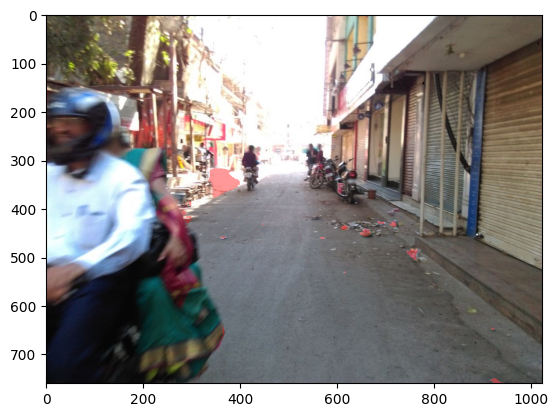

In [32]:
plt.imshow(r)

In [ ]:
plt.imshow(r)

In [ ]:
resize_and_pad_raw(
    np.zeros(100, 23, 3),
)

In [14]:
print(e.unpadded.shape)
print(e.mask.shape)

e.meta

(50, 0)
(50, 50)


{'orig_h': 100,
 'orig_w': 23,
 'scale': 1.0,
 'new_h': 100,
 'new_w': 23,
 'pad_left': 38,
 'pad_right': 39,
 'pad_top': 0,
 'pad_bottom': 0,
 'target_size': 100}

In [92]:
print(e.cause)

print(e.mask.shape)
e.meta

OpenCV(4.13.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'

(50, 50)


{'orig_h': 100,
 'orig_w': 23,
 'scale': 1.0,
 'new_h': 100,
 'new_w': 23,
 'pad_left': 38,
 'pad_right': 39,
 'pad_top': 0,
 'pad_bottom': 0}

{'orig_h': 100, 'orig_w': 23, 'scale': 1.0, 'new_h': 100, 'new_w': 23, 'pad_left': 38, 'pad_right': 39, 'pad_top': 0, 'pad_bottom': 0} (50, 50)


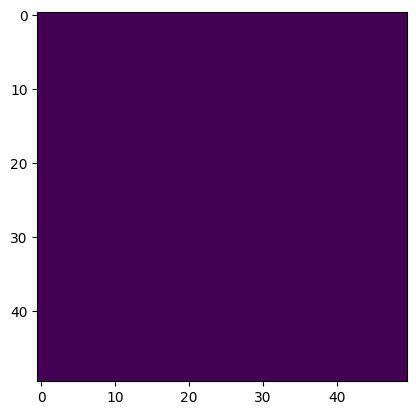

In [76]:
print(e.meta, e.mask.shape)
plt.imshow(e.mask)

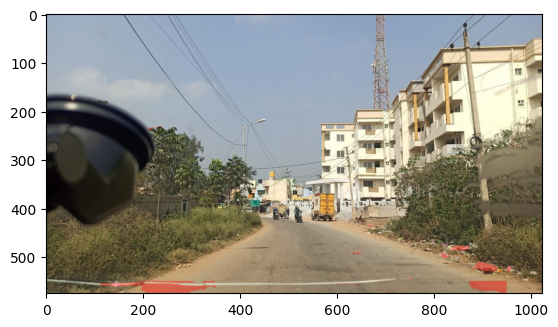

In [56]:
plt.imshow(res)

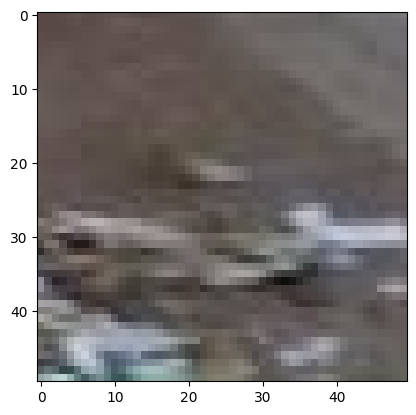

In [33]:
img = plt.imread('/Users/hariomnarang/Desktop/personal/roads/datasets/test-pos-samples/stridded_mapillary_neg_with_elev/scale=50_to_50/269626184842101/image.jpg')
plt.imshow(img[400:450, 650:700])

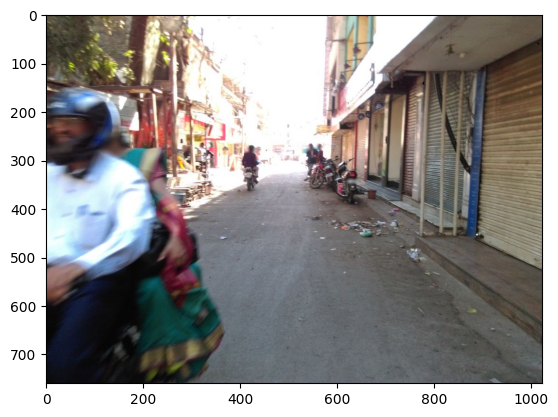

In [41]:
plt.imshow(img)

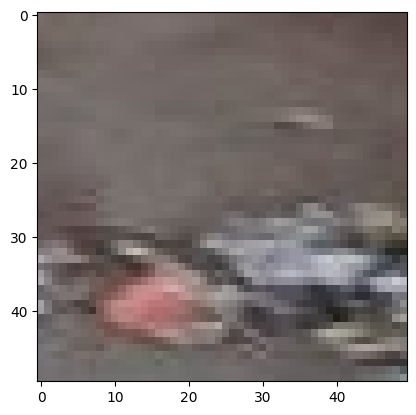

In [59]:
plt.imshow(img[400:450, 600:650])

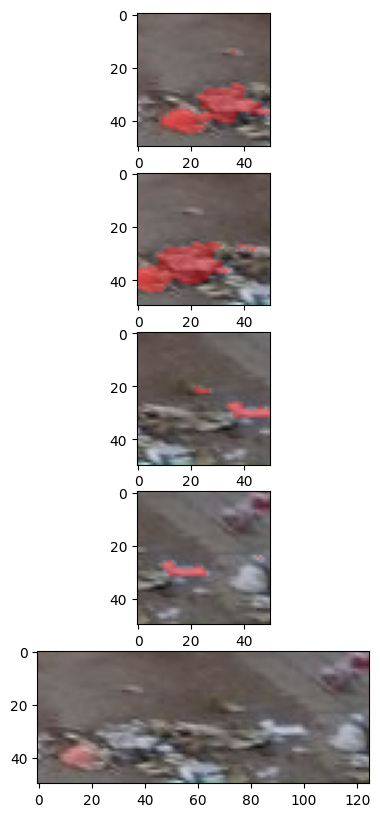

In [65]:
from mtrain.smallnet.unet.predict import overlay_mask_on_img

learner = load_learner("/Users/hariomnarang/Desktop/gdrive-sync/garbage/experiments/T008-engulf-v2-only-uncentered/log/export_iter_4.pkl")
crops = [
    img[400:450, 600:650],
    img[400:450, 615:665],
    img[400:450, 650:700],
    img[400:450, 675:725],
]
masks = [
    learner.predict(c)[0].numpy().astype(bool) for c in crops
]
ovls = [overlay_mask_on_img(c, m) for c, m in zip(crops, masks)]

_, axs = plt.subplots(5, 1, figsize=(20,10))
for i in range(4):
    axs[i].imshow(ovls[i])
axs[4].imshow(img[400:450, 600:725])
plt.show()
# crop = img[400:450, 600:650]
# mask, _, _ = learner.predict(crop)
# mask = mask.numpy().astype(bool)

# res = overlay_mask_on_img(crop, mask)
# # print(mask.shape, res.shape)
# plt.imshow(res)

In [ ]:
plt.imshow(m)

In [ ]:
import shutil


def run_single_exp(model_path, model_code, tile_size, shrink_to, strides):
    print(red(f"running: {model_code}"))
    learner = load_learner(model_path)
    outd = OUT / model_code
    outd.mkdir(parents=True, exist_ok=True)

    for i, img in enumerate(IMAGES):
        print(red(f"{i} / {len(IMAGES)}"))
        overlayed, mask = _predict_with_strides(
            img, tile_size, shrink_to, learner, strides=strides
        )
        # overlayed, mask = predict_unet_with_resizer(img, tile_size, shrink_to, learner)
        dest_dir = outd / Path(img).stem
        dest_dir.mkdir(parents=True, exist_ok=True)
        plt.imsave(dest_dir / "overlay.jpg", overlayed)
        plt.imsave(dest_dir / "mask.png", mask)
        shutil.copy(img, dest_dir / "image.jpg")

In [7]:
for exp in EXPERIMENTS:
    run_single_exp(**exp)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


running: scale=50_to_50
0 / 80


32it [00:05,  6.17it/s]
100%|██████████| 252/252 [00:00<00:00, 166032.77it/s]
30it [00:04,  6.27it/s]
100%|██████████| 240/240 [00:00<00:00, 153731.36it/s]
/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


1 / 80


32it [00:05,  5.35it/s]
100%|██████████| 252/252 [00:00<00:00, 154121.41it/s]
30it [00:04,  6.24it/s]
100%|██████████| 240/240 [00:00<00:00, 149930.44it/s]


...

42it [00:06,  6.55it/s]
100%|██████████| 336/336 [00:00<00:00, 183119.30it/s]
38it [00:05,  6.78it/s]
100%|██████████| 300/300 [00:00<00:00, 193672.65it/s]


78 / 80


32it [00:04,  6.68it/s]
100%|██████████| 252/252 [00:00<00:00, 154504.40it/s]
30it [00:04,  6.83it/s]
100%|██████████| 240/240 [00:00<00:00, 160521.92it/s]


79 / 80


35it [00:05,  6.55it/s]
100%|██████████| 273/273 [00:00<00:00, 160888.72it/s]
33it [00:04,  6.89it/s]
100%|██████████| 260/260 [00:00<00:00, 157090.04it/s]


In [8]:
photo_to_code = OUT / "photo-to-code"
photo_to_code.mkdir(parents=True, exist_ok=True)
photo_to_code = photo_to_code.resolve()

for img in tqdm(OUT.rglob("*.jpg")):
    img = img.resolve()
    if img.is_relative_to(photo_to_code):
        continue

    img_dir = photo_to_code / img.stem
    img_dir.mkdir(parents=True, exist_ok=True)
    link = img_dir / f"{img.parent.name}.jpg"
    if link.exists():
        link.unlink()
    link.symlink_to(img)

160it [00:00, 2012.33it/s]
